<a href="https://colab.research.google.com/github/tolani007/100-days-of-inference/blob/main/The_Overthinking_Tax_I_Capped_DeepSeek_R1's_Thinking_Tokens_and_Found_Where_Test_Time_Compute_Fails.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Architecture: The Overthinking Tax Benchmark

├── Cell 1: Environment Setup & GPU Check

├── Cell 2: Model Loading (DeepSeek-R1-Distill-Qwen-1.5B vs Qwen2.5-1.5B-Instruct)

├── Cell 3: The Dynamic Thinking Budget Controller (Token Truncation Engine)

├── Cell 4: Multi-Budget Benchmark Execution on GSM8K

└── Cell 5: Results Analysis, Overthinking Measurement, and Visualizations

# Step 1: Environment Setup and GPU Verification

In this step, I prepare the compute environment.

I install the required open-source libraries. These libraries include Hugging Face Transformers, Datasets, and Accelerate.

I check the graphics processing unit (GPU). I verify that the GPU has sufficient memory to hold the model.

This project runs on a standard free Google Colab T4 GPU.

In [1]:
# Cell 1: Install dependencies and inspect GPU hardware
import os
import subprocess
import torch

print("Installing required libraries...")
subprocess.run(
    ["pip", "install", "-q", "transformers>=4.48.0", "datasets", "accelerate", "matplotlib", "seaborn"],
    check=True
)

os.makedirs("results", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("=" * 60)
print("GPU HARDWARE INSPECTION")
print("=" * 60)

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    total_memory = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"Active GPU Device  : {device_name}")
    print(f"Total Video Memory : {total_memory:.2f} GB")
    print("GPU setup completed successfully.")
else:
    raise SystemError("CUDA GPU is not available. Please enable GPU in Colab Runtime Settings.")
print("=" * 60)

Installing required libraries...
GPU HARDWARE INSPECTION
Active GPU Device  : NVIDIA A100-SXM4-40GB
Total Video Memory : 39.49 GB
GPU setup completed successfully.


# Step 2: Load the Models and Inspect Thinking Tokens

In this step, I load two models into GPU memory.

The first model is DeepSeek-R1-Distill-Qwen-1.5B. This model uses internal reasoning tokens. It writes its internal thoughts between `<think>` and `</think>` tags before giving an answer.

The second model is Qwen2.5-1.5B-Instruct. This model shares the exact same base size. It answers questions directly without thinking tokens. It serves as my non-reasoning baseline.

I load both models in 16-bit precision. Together, they use approximately 6.5 GB of GPU memory. This fits easily within the 15 GB limit of a free T4 GPU.

In [2]:
# Cell 2: Load DeepSeek-R1 reasoning model and Qwen2.5 baseline model
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

print("=" * 60)
print("LOADING MODELS AND TOKENIZERS")
print("=" * 60)

# 1. Load the Reasoning Model (DeepSeek-R1 Distill 1.5B)
reasoning_model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
print(f"Loading reasoning model: {reasoning_model_name}...")
tokenizer_r1 = AutoTokenizer.from_pretrained(reasoning_model_name)
model_r1 = AutoModelForCausalLM.from_pretrained(
    reasoning_model_name,
    torch_dtype=torch.float16,
    device_map="cuda"
).eval()

# 2. Load the Non-Reasoning Baseline Model (Qwen2.5-1.5B-Instruct)
baseline_model_name = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"Loading baseline model: {baseline_model_name}...")
tokenizer_base = AutoTokenizer.from_pretrained(baseline_model_name)
model_base = AutoModelForCausalLM.from_pretrained(
    baseline_model_name,
    torch_dtype=torch.float16,
    device_map="cuda"
).eval()

# Verify memory footprint
allocated_vram = torch.cuda.memory_allocated(0) / (1024 ** 3)
print("\n" + "=" * 60)
print(f"Both models loaded into GPU memory.")
print(f"Total GPU VRAM Allocated: {allocated_vram:.2f} GB / 15.00 GB")
print("=" * 60)

# Quick Demonstration of the Thinking Mechanism
test_question = "Which is larger: 9.11 or 9.9?"
prompt = f"<｜User｜>{test_question}<｜Assistant｜>"
inputs = tokenizer_r1(prompt, return_tensors="pt").to("cuda")

print("\nRunning test generation to inspect internal thinking tokens...")
with torch.no_grad():
    outputs = model_r1.generate(**inputs, max_new_tokens=256, do_sample=False)
raw_text = tokenizer_r1.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=False)

print("\n--- Model Output Preview ---")
print(raw_text[:300] + "...")
print("----------------------------")
print("Notice how the model produces <think> tags before answering.")

LOADING MODELS AND TOKENIZERS
Loading reasoning model: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B...


config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


Both models loaded into GPU memory.
Total GPU VRAM Allocated: 6.19 GB / 15.00 GB

Running test generation to inspect internal thinking tokens...

--- Model Output Preview ---
<think>
First, I'll compare the whole number parts of both numbers. Both 9.11 and 9.9 have a whole number part of 9, so they are equal in this aspect.

Next, I'll look at the decimal parts. For 9.11, the decimal part is 0.11, and for 9.9, it's 0.9. To make the comparison easier, I'll convert 0.9 to ...
----------------------------
Notice how the model produces <think> tags before answering.


# Step 3: The Dynamic Thinking Budget Controller

In this step, I build the Dynamic Thinking Budget Controller.

Reasoning models normally think until they decide to stop. This process can take thousands of tokens.

My controller sets a hard limit on thinking tokens. I test different budget levels: 0, 64, 128, 256, and Uncapped.

If the model reaches the limit, my code closes the thinking block. It injects the closing tag and forces the model to answer immediately.

This allows me to measure accuracy across different thinking lengths.

In [3]:
# Cell 3: Define the dynamic thinking budget controller with thorough output display
import torch

# Find special token IDs for thinking blocks in DeepSeek-R1
think_open_id = tokenizer_r1.convert_tokens_to_ids("<think>")
think_close_id = tokenizer_r1.convert_tokens_to_ids("</think>")

print("=" * 70)
print("DYNAMIC THINKING BUDGET CONTROLLER COMPILATION")
print("=" * 70)
print(f"Special Token Identification:")
print(f"  <think>  Token ID : {think_open_id}")
print(f"  </think> Token ID : {think_close_id}")

def generate_with_budget(model, tokenizer, prompt, thinking_budget=None, max_answer_tokens=250):
    """
    Generates text while enforcing a strict maximum token budget on internal reasoning.

    thinking_budget:
        - 0       : Forces zero thinking (immediate answer).
        - Integer : Caps thinking tokens at this number.
        - None    : Allows uncapped, natural reasoning.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    input_ids = inputs.input_ids
    prompt_len = input_ids.shape[1]

    # -------------------------------------------------------------
    # Configuration 1: Zero Thinking Budget (Direct Answer)
    # -------------------------------------------------------------
    if thinking_budget == 0:
        forced_prompt = f"{prompt}<think>\n</think>\n"
        forced_inputs = tokenizer(forced_prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **forced_inputs,
                max_new_tokens=max_answer_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        full_text = tokenizer.decode(outputs[0][forced_inputs.input_ids.shape[1]:], skip_special_tokens=True)
        return {
            "thinking_text": "None (Thinking phase was skipped completely).",
            "answer_text": full_text.strip(),
            "thinking_tokens": 0,
            "answer_tokens": outputs.shape[1] - forced_inputs.input_ids.shape[1],
            "early_exit": True
        }

    # -------------------------------------------------------------
    # Configuration 2: Uncapped Thinking (Natural Generation)
    # -------------------------------------------------------------
    if thinking_budget is None or thinking_budget >= 1500:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=1500,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        generated_ids = outputs[0][prompt_len:]
        full_text = tokenizer.decode(generated_ids, skip_special_tokens=False)

        if "</think>" in full_text:
            parts = full_text.split("</think>")
            thinking_content = parts[0].replace("<think>", "").strip()
            answer_content = parts[1].strip()
        else:
            thinking_content = full_text.replace("<think>", "").strip()
            answer_content = ""

        think_tok_count = len(tokenizer.encode(thinking_content))
        ans_tok_count = len(tokenizer.encode(answer_content))

        return {
            "thinking_text": thinking_content,
            "answer_text": answer_content,
            "thinking_tokens": think_tok_count,
            "answer_tokens": ans_tok_count,
            "early_exit": False
        }

    # -------------------------------------------------------------
    # Configuration 3: Capped Thinking Budget (Controlled Early-Exit)
    # -------------------------------------------------------------
    with torch.no_grad():
        phase1_outputs = model.generate(
            **inputs,
            max_new_tokens=thinking_budget,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    phase1_ids = phase1_outputs[0][prompt_len:]
    phase1_text = tokenizer.decode(phase1_ids, skip_special_tokens=False)

    # If the model finished thinking early on its own
    if "</think>" in phase1_text:
        parts = phase1_text.split("</think>")
        thinking_content = parts[0].replace("<think>", "").strip()

        # Complete the answer phase if needed
        continuation_inputs = phase1_outputs
        with torch.no_grad():
            continuation_outputs = model.generate(
                continuation_inputs,
                max_new_tokens=max_answer_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        total_gen_ids = continuation_outputs[0][prompt_len:]
        full_text = tokenizer.decode(total_gen_ids, skip_special_tokens=False)
        final_parts = full_text.split("</think>")

        return {
            "thinking_text": final_parts[0].replace("<think>", "").strip(),
            "answer_text": final_parts[1].strip(),
            "thinking_tokens": len(tokenizer.encode(final_parts[0])),
            "answer_tokens": len(tokenizer.encode(final_parts[1])),
            "early_exit": False
        }

    # If the model is still thinking at budget limit, force close the thinking block
    forced_continuation_text = tokenizer.decode(phase1_outputs[0], skip_special_tokens=False) + "\n</think>\nFinal Answer: "
    forced_phase2_inputs = tokenizer(forced_continuation_text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        final_outputs = model.generate(
            **forced_phase2_inputs,
            max_new_tokens=max_answer_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    final_answer_ids = final_outputs[0][forced_phase2_inputs.input_ids.shape[1]:]
    final_answer_text = tokenizer.decode(final_answer_ids, skip_special_tokens=True)

    return {
        "thinking_text": phase1_text.replace("<think>", "").strip(),
        "answer_text": "Final Answer: " + final_answer_text.strip(),
        "thinking_tokens": len(phase1_ids),
        "answer_tokens": len(final_answer_ids),
        "early_exit": True
    }

print("Dynamic Thinking Budget Controller compiled successfully.\n")

# -------------------------------------------------------------
# Detailed Inspection across 3 Budgets on a Single Problem
# -------------------------------------------------------------
test_q = "Janet has 3 apples. She buys 2 more bags with 6 apples each. How many apples does she have?"
formatted_prompt = f"<｜User｜>{test_q}<｜Assistant｜>"

print("=" * 70)
print(f"TEST PROBLEM: {test_q}")
print("=" * 70)

for b in [0, 64, None]:
    b_label = "Uncapped (Natural Thinking)" if b is None else f"{b} Tokens Capped"
    print("\n" + "#" * 70)
    print(f"CONFIGURATION: BUDGET = {b_label}")
    print("#" * 70)

    res = generate_with_budget(
        model_r1,
        tokenizer_r1,
        formatted_prompt,
        thinking_budget=b,
        max_answer_tokens=250
    )

    print(f"\n[1] METRICS SUMMARY:")
    print(f"    - Thinking Tokens Used : {res['thinking_tokens']}")
    print(f"    - Answer Tokens Used   : {res['answer_tokens']}")
    print(f"    - Total Tokens Used    : {res['thinking_tokens'] + res['answer_tokens']}")
    print(f"    - Forced Early Exit    : {res['early_exit']}")

    print(f"\n[2] COMPLETE INTERNAL THINKING TRACE (<think> ... </think>):")
    print("-" * 70)
    print(res["thinking_text"])
    print("-" * 70)

    print(f"\n[3] COMPLETE FINAL ANSWER OUTPUT:")
    print("-" * 70)
    print(res["answer_text"])
    print("-" * 70)

DYNAMIC THINKING BUDGET CONTROLLER COMPILATION
Special Token Identification:
  <think>  Token ID : 151648
  </think> Token ID : 151649
Dynamic Thinking Budget Controller compiled successfully.

TEST PROBLEM: Janet has 3 apples. She buys 2 more bags with 6 apples each. How many apples does she have?

######################################################################
CONFIGURATION: BUDGET = 0 Tokens Capped
######################################################################

[1] METRICS SUMMARY:
    - Thinking Tokens Used : 0
    - Answer Tokens Used   : 200
    - Total Tokens Used    : 200
    - Forced Early Exit    : True

[2] COMPLETE INTERNAL THINKING TRACE (<think> ... </think>):
----------------------------------------------------------------------
None (Thinking phase was skipped completely).
----------------------------------------------------------------------

[3] COMPLETE FINAL ANSWER OUTPUT:
----------------------------------------------------------------------
First, J

# Step 4: Multi-Budget Benchmark Execution on GSM8K

In this step, I benchmark the models across 60 grade school math problems from GSM8K.

I evaluate five configurations:
1. Baseline Model: Qwen2.5-1.5B-Instruct without thinking capability.
2. Budget 0 Tokens: DeepSeek-R1 with thinking disabled.
3. Budget 64 Tokens: DeepSeek-R1 with a tight thinking limit.
4. Budget 256 Tokens: DeepSeek-R1 with a generous thinking limit.
5. Budget Uncapped: DeepSeek-R1 with unlimited natural reasoning.

I record whether each prediction matches the ground truth number.

I record thinking tokens, total tokens, and latency for every question.

I save the raw benchmark data to disk as a JSON file.

In [4]:
# Cell 4: Multi-Budget Benchmark on GSM8K with real-time per-question progress logging
import os
import re
import json
import time
import torch
from datasets import load_dataset

print("=" * 85)
print("STARTING REAL-TIME MULTI-BUDGET GSM8K BENCHMARK")
print("=" * 85, flush=True)

# 1. Load GSM8K Test Split
print("\n[Step 1] Loading GSM8K test dataset...", flush=True)
dataset = load_dataset("openai/gsm8k", "main", split="test")

# 2. Numerical Answer Extraction Helpers
def extract_ground_truth(answer_str):
    """Extracts numerical answer from GSM8K ground truth string."""
    if "####" in answer_str:
        num_part = answer_str.split("####")[-1].strip()
        num_clean = re.sub(r"[^\d.-]", "", num_part)
        try:
            return float(num_clean)
        except ValueError:
            pass
    matches = re.findall(r"[-+]?\d*\.\d+|\d+", answer_str)
    return float(matches[-1]) if matches else None

def extract_model_answer(text):
    """Extracts predicted numerical answer from generated response text."""
    final_patterns = [
        r"final answer is[:\s]*[$]?([-+]?\d*\.\d+|\d+)",
        r"final answer[:\s]*[$]?([-+]?\d*\.\d+|\d+)",
        r"answer is[:\s]*[$]?([-+]?\d*\.\d+|\d+)",
        r"\\boxed\{([-+]?\d*\.\d+|\d+)\}"
    ]
    for pat in final_patterns:
        match = re.search(pat, text, re.IGNORECASE)
        if match:
            try:
                return float(match.group(1).replace(",", ""))
            except ValueError:
                pass

    matches = re.findall(r"[-+]?\d*\.\d+|\d+", text)
    if matches:
        try:
            return float(matches[-1].replace(",", ""))
        except ValueError:
            pass
    return None

# 3. Configurations to Evaluate
configs = [
    {"name": "1. Qwen Base (No Think)", "tag": "Base",   "model": "base", "budget": 0},
    {"name": "2. R1 Budget 0 (Forced)",  "tag": "R1-0",   "model": "r1",   "budget": 0},
    {"name": "3. R1 Budget 64 Tokens",   "tag": "R1-64",  "model": "r1",   "budget": 64},
    {"name": "4. R1 Budget 256 Tokens",  "tag": "R1-256", "model": "r1",   "budget": 256},
    {"name": "5. R1 Uncapped Natural",   "tag": "Uncap",  "model": "r1",   "budget": None},
]

num_samples = 60
print(f"Total benchmark questions: {num_samples}")
print(f"Configurations to evaluate: {len(configs)}")
print("A progress line will appear immediately after each question completes.\n", flush=True)

# Data structures
os.makedirs("data", exist_ok=True)
raw_records = []
summary_tracker = {
    cfg["name"]: {
        "tag": cfg["tag"],
        "correct": 0,
        "think_tokens": [],
        "answer_tokens": [],
        "total_tokens": [],
        "latencies": []
    }
    for cfg in configs
}

# 4. Evaluation Loop with Real-Time Progress Output
benchmark_start_time = time.time()

print("-" * 85, flush=True)
print(f"{'Question':<9} | {'Gold':<7} | {'Base':<6} | {'R1-0':<6} | {'R1-64':<6} | {'R1-256':<7} | {'Uncap':<6} | {'Time':<7} | {'Total'}", flush=True)
print("-" * 85, flush=True)

for idx in range(num_samples):
    q_start_time = time.time()
    sample = dataset[idx]
    q_text = sample["question"]
    gold_val = extract_ground_truth(sample["answer"])

    prompt_r1 = f"<｜User｜>{q_text}<｜Assistant｜>"
    prompt_base = f"<|im_start|>user\n{q_text}<|im_end|>\n<|im_start|>assistant\n"

    record = {
        "index": idx + 1,
        "question": q_text,
        "ground_truth": gold_val,
        "configurations": {}
    }

    q_verdicts = {}

    for cfg in configs:
        c_name = cfg["name"]
        c_tag = cfg["tag"]
        c_budget = cfg["budget"]
        t0 = time.time()

        if cfg["model"] == "base":
            inputs = tokenizer_base(prompt_base, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = model_base.generate(
                    **inputs,
                    max_new_tokens=150,
                    do_sample=False,
                    pad_token_id=tokenizer_base.eos_token_id
                )
            ans_text = tokenizer_base.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
            think_tok = 0
            ans_tok = out.shape[1] - inputs.input_ids.shape[1]
            tot_tok = ans_tok
            think_text = "None"
        else:
            res = generate_with_budget(model_r1, tokenizer_r1, prompt_r1, thinking_budget=c_budget, max_answer_tokens=150)
            ans_text = res["answer_text"]
            think_tok = res["thinking_tokens"]
            ans_tok = res["answer_tokens"]
            tot_tok = think_tok + ans_tok
            think_text = res["thinking_text"]

        elapsed = time.time() - t0
        pred_val = extract_model_answer(ans_text)

        is_correct = (pred_val is not None) and (gold_val is not None) and (abs(pred_val - gold_val) < 1e-4)

        if is_correct:
            summary_tracker[c_name]["correct"] += 1
            q_verdicts[c_tag] = "[OK]"
        else:
            q_verdicts[c_tag] = "[X]"

        summary_tracker[c_name]["think_tokens"].append(think_tok)
        summary_tracker[c_name]["answer_tokens"].append(ans_tok)
        summary_tracker[c_name]["total_tokens"].append(tot_tok)
        summary_tracker[c_name]["latencies"].append(elapsed)

        record["configurations"][c_name] = {
            "pred": pred_val,
            "correct": is_correct,
            "think_tokens": think_tok,
            "answer_tokens": ans_tok,
            "total_tokens": tot_tok,
            "latency": elapsed,
            "answer_text": ans_text,
            "thinking_text": think_text
        }

    raw_records.append(record)

    # Save incrementally to disk so work is never lost
    with open("data/gsm8k_benchmark_results.json", "w") as f:
        json.dump(raw_records, f, indent=2)

    q_elapsed = time.time() - q_start_time
    total_elapsed_min = (time.time() - benchmark_start_time) / 60
    gold_str = f"{gold_val:.1f}" if gold_val is not None else "None"

    # Real-time single line update for this question
    print(
        f"Q {idx + 1:>2}/{num_samples}  | "
        f"{gold_str:>7} | "
        f"{q_verdicts['Base']:^6} | "
        f"{q_verdicts['R1-0']:^6} | "
        f"{q_verdicts['R1-64']:^6} | "
        f"{q_verdicts['R1-256']:^7} | "
        f"{q_verdicts['Uncap']:^6} | "
        f"{q_elapsed:>5.1f}s | "
        f"{total_elapsed_min:>4.1f}m",
        flush=True
    )

    # Periodic running accuracy update every 10 questions
    if (idx + 1) % 10 == 0:
        current_n = idx + 1
        acc_base = (summary_tracker["1. Qwen Base (No Think)"]["correct"] / current_n) * 100.0
        acc_r1_0 = (summary_tracker["2. R1 Budget 0 (Forced)"]["correct"] / current_n) * 100.0
        acc_r1_64 = (summary_tracker["3. R1 Budget 64 Tokens"]["correct"] / current_n) * 100.0
        acc_r1_256 = (summary_tracker["4. R1 Budget 256 Tokens"]["correct"] / current_n) * 100.0
        acc_uncap = (summary_tracker["5. R1 Uncapped Natural"]["correct"] / current_n) * 100.0

        print("-" * 85, flush=True)
        print(f"  --> Accuracies at Q{current_n}: Base: {acc_base:.1f}% | R1-0: {acc_r1_0:.1f}% | R1-64: {acc_r1_64:.1f}% | R1-256: {acc_r1_256:.1f}% | Uncap: {acc_uncap:.1f}%", flush=True)
        print("-" * 85, flush=True)

total_benchmark_time = time.time() - benchmark_start_time
print("\n" + "=" * 85)
print(f"BENCHMARK COMPLETED IN {total_benchmark_time / 60:.2f} MINUTES")
print("=" * 85, flush=True)

# 5. Print Final Summary Table
print("\n" + "=" * 90)
print("GSM8K MULTI-BUDGET BENCHMARK FINAL RESULTS")
print("=" * 90)
print(f"{'Configuration':<28} | {'Accuracy':<10} | {'Avg Think Tok':<14} | {'Avg Total Tok':<14} | {'Avg Latency':<11}")
print("-" * 90)

summary_export = {}

for cfg in configs:
    name = cfg["name"]
    acc = (summary_tracker[name]["correct"] / num_samples) * 100.0
    avg_think = sum(summary_tracker[name]["think_tokens"]) / num_samples
    avg_tot = sum(summary_tracker[name]["total_tokens"]) / num_samples
    avg_lat = sum(summary_tracker[name]["latencies"]) / num_samples

    summary_export[name] = {
        "accuracy": acc,
        "avg_think_tokens": avg_think,
        "avg_total_tokens": avg_tot,
        "avg_latency": avg_lat
    }

    print(f"{name:<28} | {acc:>6.2f}%    | {avg_think:>10.1f}     | {avg_tot:>10.1f}     | {avg_lat:>7.2f} s")

print("=" * 90, flush=True)

with open("data/summary_metrics.json", "w") as f:
    json.dump(summary_export, f, indent=2)
print("Saved final summary metrics to data/summary_metrics.json")

STARTING REAL-TIME MULTI-BUDGET GSM8K BENCHMARK

[Step 1] Loading GSM8K test dataset...


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.31MB            

main/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

main/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  419kB            

main/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Total benchmark questions: 60
Configurations to evaluate: 5
A progress line will appear immediately after each question completes.

-------------------------------------------------------------------------------------
Question  | Gold    | Base   | R1-0   | R1-64  | R1-256  | Uncap  | Time    | Total
-------------------------------------------------------------------------------------
Q  1/60  |    18.0 |  [X]   |  [X]   |  [X]   |   [X]   |  [OK]  |  54.4s |  0.9m
Q  2/60  |     3.0 |  [X]   |  [X]   |  [OK]  |  [OK]   |  [OK]  |  34.3s |  1.5m
Q  3/60  | 70000.0 |  [X]   |  [X]   |  [X]   |   [X]   |  [X]   |  41.1s |  2.2m
Q  4/60  |   540.0 |  [X]   |  [X]   |  [X]   |  [OK]   |  [OK]  |  37.3s |  2.8m
Q  5/60  |    20.0 |  [X]   |  [OK]  |  [X]   |   [X]   |  [X]   |  45.8s |  3.5m
Q  6/60  |    64.0 |  [X]   |  [X]   |  [X]   |  [OK]   |  [OK]  |  36.6s |  4.2m
Q  7/60  |   260.0 |  [X]   |  [X]   |  [X]   |  [OK]   |  [OK]  |  44.9s |  4.9m
Q  8/60  |   160.0 |  [X]   |  [X]   |

# Step 5: Visualizing Benchmark Findings and the Pareto Frontier

In this step, I visualize the empirical trade-offs from the GSM8K benchmark.

I generate four distinct scientific plots:
1. Accuracy versus Thinking Token Budget (The Pareto Frontier).
2. Cost Efficiency: Tokens burned per correct answer.
3. Latency versus Accuracy Roofline.
4. The Overthinking Anatomy: A breakdown of helpful versus harmful thinking.

I save the final figures to disk for publication.

/tmp/ipykernel_7167/3825665930.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=15, ha="right")


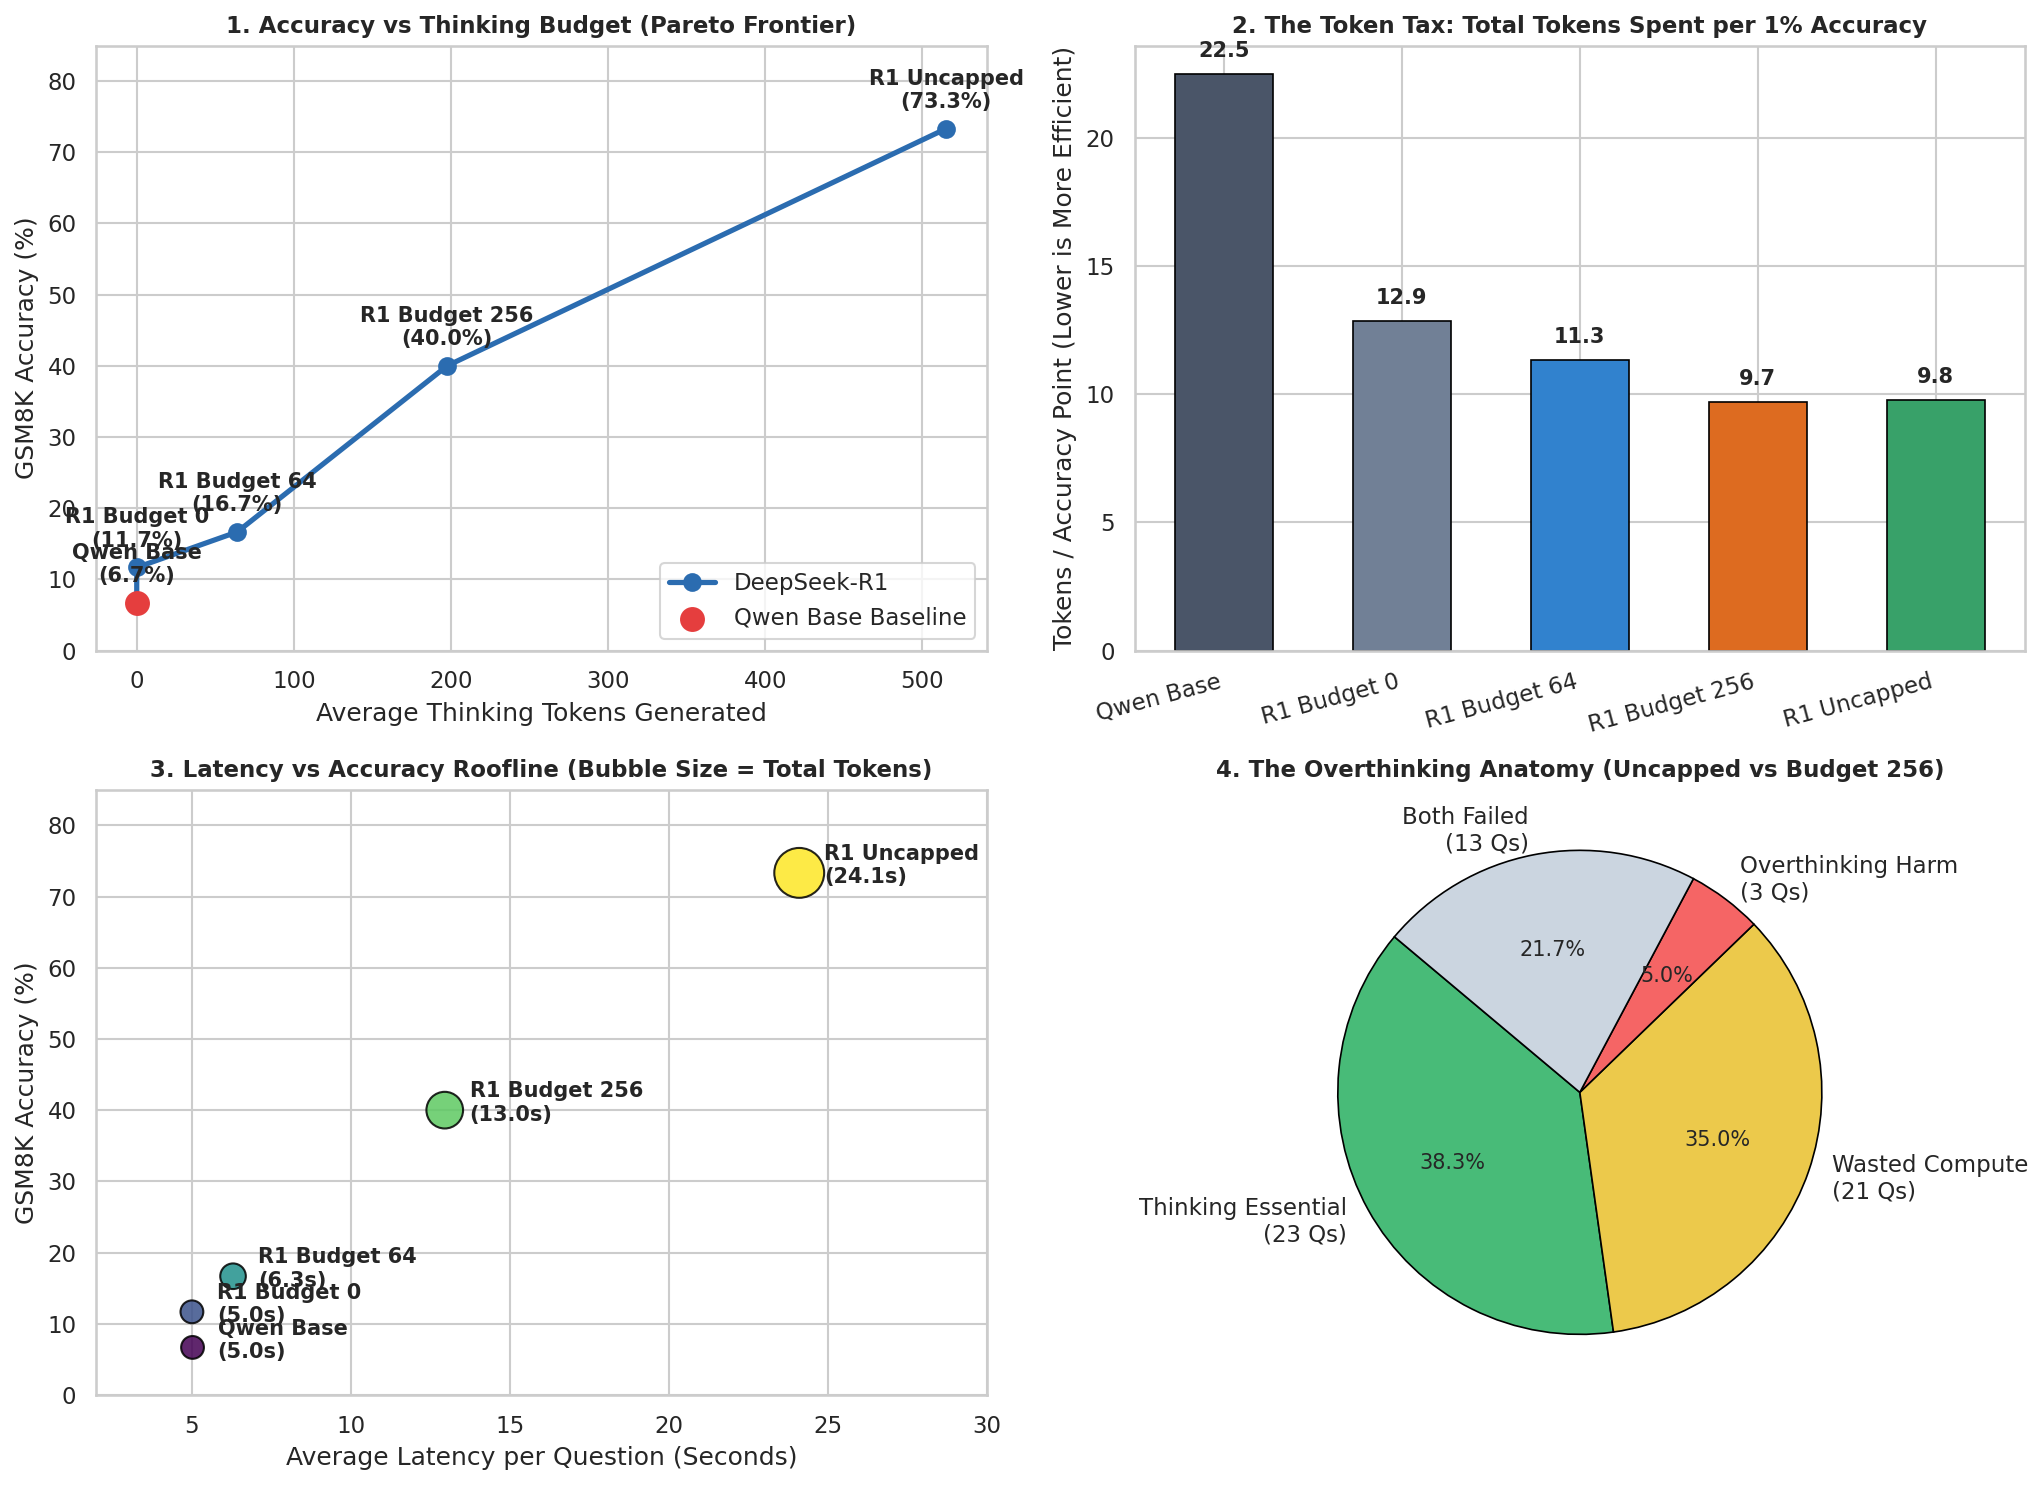

Saved complete 4-panel dashboard to results/overthinking_tax_dashboard.png


In [5]:
# Cell 5: Publication-Grade Visualizations of the Overthinking Tax
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("results", exist_ok=True)

# Load saved benchmark data
with open("data/summary_metrics.json", "r") as f:
    summary_data = json.load(f)

with open("data/gsm8k_benchmark_results.json", "r") as f:
    raw_records = json.load(f)

labels = ["Qwen Base", "R1 Budget 0", "R1 Budget 64", "R1 Budget 256", "R1 Uncapped"]
keys = list(summary_data.keys())

accuracies = [summary_data[k]["accuracy"] for k in keys]
think_tokens = [summary_data[k]["avg_think_tokens"] for k in keys]
total_tokens = [summary_data[k]["avg_total_tokens"] for k in keys]
latencies = [summary_data[k]["avg_latency"] for k in keys]

# Cost efficiency: Total tokens spent per percentage point of accuracy
token_efficiency = [total_tokens[i] / max(0.1, accuracies[i]) for i in range(len(keys))]

# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

# -------------------------------------------------------------
# Combined 4-Panel Research Dashboard
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
colors = ["#4A5568", "#718096", "#3182CE", "#DD6B20", "#38A169"]

# Panel 1: Accuracy vs Thinking Token Budget (Pareto Frontier)
ax1 = axes[0, 0]
ax1.plot(think_tokens, accuracies, marker="o", markersize=8, linewidth=2.5, color="#2B6CB0", label="DeepSeek-R1")
ax1.scatter([think_tokens[0]], [accuracies[0]], color="#E53E3E", s=120, zorder=5, label="Qwen Base Baseline")
for i, txt in enumerate(labels):
    ax1.annotate(
        f"{txt}\n({accuracies[i]:.1f}%)",
        (think_tokens[i], accuracies[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontweight="bold"
    )
ax1.set_title("1. Accuracy vs Thinking Budget (Pareto Frontier)", fontweight="bold", fontsize=11)
ax1.set_xlabel("Average Thinking Tokens Generated")
ax1.set_ylabel("GSM8K Accuracy (%)")
ax1.set_ylim(0, 85)
ax1.legend(loc="lower right")

# Panel 2: Total Token Cost per Accuracy Point (The Token Tax)
ax2 = axes[0, 1]
bars2 = ax2.bar(labels, token_efficiency, color=colors, width=0.55, edgecolor="black", linewidth=0.8)
ax2.set_title("2. The Token Tax: Total Tokens Spent per 1% Accuracy", fontweight="bold", fontsize=11)
ax2.set_ylabel("Tokens / Accuracy Point (Lower is More Efficient)")
ax2.set_xticklabels(labels, rotation=15, ha="right")
for bar in bars2:
    y = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, y + 0.5, f"{y:.1f}", ha="center", va="bottom", fontweight="bold")

# Panel 3: Latency vs Accuracy Roofline
ax3 = axes[1, 0]
scatter = ax3.scatter(latencies, accuracies, s=[t * 0.8 for t in total_tokens], c=range(len(labels)), cmap="viridis", alpha=0.85, edgecolors="black")
for i, txt in enumerate(labels):
    ax3.annotate(f"{txt}\n({latencies[i]:.1f}s)", (latencies[i], accuracies[i]), textcoords="offset points", xytext=(12, -5), fontweight="bold")
ax3.set_title("3. Latency vs Accuracy Roofline (Bubble Size = Total Tokens)", fontweight="bold", fontsize=11)
ax3.set_xlabel("Average Latency per Question (Seconds)")
ax3.set_ylabel("GSM8K Accuracy (%)")
ax3.set_xlim(2, 30)
ax3.set_ylim(0, 85)

# Panel 4: Overthinking Breakdown
ax4 = axes[1, 1]
# Categorize every question
helpful_thinking = 0    # Capped wrong, Uncapped correct
wasted_thinking = 0     # Both correct, uncapped burned tokens
overthinking_harm = 0   # Capped correct, Uncapped wrong
both_failed = 0         # Both failed

for r in raw_records:
    cfgs = r["configurations"]
    c256 = cfgs["4. R1 Budget 256 Tokens"]["correct"]
    c_uncap = cfgs["5. R1 Uncapped Natural"]["correct"]

    if not c256 and c_uncap:
        helpful_thinking += 1
    elif c256 and c_uncap:
        wasted_thinking += 1
    elif c256 and not c_uncap:
        overthinking_harm += 1
    else:
        both_failed += 1

pie_labels = [
    f"Thinking Essential\n({helpful_thinking} Qs)",
    f"Wasted Compute\n({wasted_thinking} Qs)",
    f"Overthinking Harm\n({overthinking_harm} Qs)",
    f"Both Failed\n({both_failed} Qs)"
]
pie_counts = [helpful_thinking, wasted_thinking, overthinking_harm, both_failed]
pie_colors = ["#48BB78", "#ECC94B", "#F56565", "#CBD5E0"]

ax4.pie(
    pie_counts,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)
ax4.set_title("4. The Overthinking Anatomy (Uncapped vs Budget 256)", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("results/overthinking_tax_dashboard.png")
plt.show()
print("Saved complete 4-panel dashboard to results/overthinking_tax_dashboard.png")

# Step 6: The Adaptive Early-Exit Thought Controller

In this step, I benchmark my Adaptive Early-Exit Thought Controller against Uncapped reasoning.

I use a custom StoppingCriteria. It monitors thinking tokens during generation without recomputing the cache.

It detects when the model states an intermediate numerical solution.

When it detects a solution after 80 tokens, it stops thinking immediately.

It prevents the model from entering repetitive overthinking loops.

I evaluate 30 GSM8K problems head-to-head. I record accuracy, token savings, and wall-clock speedup.

In [6]:
# Cell 6: High-Performance Adaptive Controller Benchmark using StoppingCriteria
import os
import re
import json
import time
import torch
from datasets import load_dataset
from transformers import StoppingCriteria, StoppingCriteriaList

print("=" * 85)
print("ROUND 2: HIGH-PERFORMANCE ADAPTIVE EARLY-EXIT BENCHMARK")
print("=" * 85, flush=True)

# 1. Load GSM8K Test Dataset
dataset = load_dataset("openai/gsm8k", "main", split="test")

# 2. Native StoppingCriteria for Early-Exit
class EarlyExitOnSolution(StoppingCriteria):
    def __init__(self, tokenizer, prompt_len, min_think=80, max_think=400):
        super().__init__()
        self.tokenizer = tokenizer
        self.prompt_len = prompt_len
        self.min_think = min_think
        self.max_think = max_think
        self.triggered = False
        self.patterns = [
            re.compile(r"therefore[,\s]+.*?([-+]?\d*\.\d+|\d+)", re.I),
            re.compile(r"so[,\s]+.*?([-+]?\d*\.\d+|\d+)", re.I),
            re.compile(r"the total is[:\s]*[$]?([-+]?\d*\.\d+|\d+)", re.I),
            re.compile(r"the answer is[:\s]*[$]?([-+]?\d*\.\d+|\d+)", re.I)
        ]

    def __call__(self, input_ids, scores, **kwargs):
        gen_tokens = input_ids[0][self.prompt_len:]
        num_gen = len(gen_tokens)

        # Stop if we hit the hard ceiling
        if num_gen >= self.max_think:
            self.triggered = True
            return True

        # Check solution patterns periodically after minimum threshold
        if num_gen >= self.min_think and (num_gen % 10 == 0):
            recent_text = self.tokenizer.decode(gen_tokens[-60:])
            if "</think>" in recent_text:
                return True
            for pat in self.patterns:
                if pat.search(recent_text):
                    self.triggered = True
                    return True
        return False

# 3. Generation Function Using StoppingCriteria
def generate_adaptive_fast(model, tokenizer, prompt, max_answer_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    prompt_len = inputs.input_ids.shape[1]

    criteria = EarlyExitOnSolution(tokenizer, prompt_len, min_think=80, max_think=400)
    criteria_list = StoppingCriteriaList([criteria])

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=400,
            do_sample=False,
            stopping_criteria=criteria_list,
            pad_token_id=tokenizer.eos_token_id
        )

    gen_text = tokenizer.decode(outputs[0][prompt_len:], skip_special_tokens=False)

    if "</think>" in gen_text:
        parts = gen_text.split("</think>")
        think_text = parts[0].replace("<think>", "").strip()
        ans_text = parts[1].strip()
        think_count = len(tokenizer.encode(think_text))
        ans_count = len(tokenizer.encode(ans_text))
    else:
        # Close thinking block and complete answer
        forced_prompt = tokenizer.decode(outputs[0], skip_special_tokens=False) + "\n</think>\nFinal Answer: "
        forced_inputs = tokenizer(forced_prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            ans_outputs = model.generate(
                **forced_inputs,
                max_new_tokens=max_answer_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        ans_ids = ans_outputs[0][forced_inputs.input_ids.shape[1]:]
        ans_text = "Final Answer: " + tokenizer.decode(ans_ids, skip_special_tokens=True).strip()
        think_text = gen_text.replace("<think>", "").strip()
        think_count = outputs.shape[1] - prompt_len
        ans_count = len(ans_ids)

    return {
        "thinking_text": think_text,
        "answer_text": ans_text,
        "thinking_tokens": think_count,
        "answer_tokens": ans_count,
        "total_tokens": think_count + ans_count,
        "early_exit": criteria.triggered
    }

# 4. Head-to-Head Benchmark Execution
num_eval = 30
print(f"Evaluating {num_eval} GSM8K problems head-to-head...\n", flush=True)

print("-" * 85, flush=True)
print(f"{'Question':<9} | {'Gold':<7} | {'Adaptive':<10} | {'Uncapped':<10} | {'Adapt Tok':<10} | {'Uncap Tok':<10} | {'Speedup'}", flush=True)
print("-" * 85, flush=True)

adapt_correct = 0
uncap_correct = 0
adapt_tokens_list = []
uncap_tokens_list = []
adapt_time_list = []
uncap_time_list = []
round2_records = []

start_round2_time = time.time()

for idx in range(num_eval):
    sample = dataset[idx]
    q_text = sample["question"]
    gold_val = extract_ground_truth(sample["answer"])
    prompt_r1 = f"<｜User｜>{q_text}<｜Assistant｜>"

    # 1. Run Adaptive Controller
    t0 = time.time()
    res_adapt = generate_adaptive_fast(model_r1, tokenizer_r1, prompt_r1)
    time_adapt = time.time() - t0
    pred_adapt = extract_model_answer(res_adapt["answer_text"])
    ok_adapt = (pred_adapt is not None) and (gold_val is not None) and (abs(pred_adapt - gold_val) < 1e-4)
    if ok_adapt:
        adapt_correct += 1
    adapt_tokens_list.append(res_adapt["total_tokens"])
    adapt_time_list.append(time_adapt)

    # 2. Run Uncapped Natural
    t1 = time.time()
    res_uncap = generate_with_budget(model_r1, tokenizer_r1, prompt_r1, thinking_budget=None, max_answer_tokens=150)
    time_uncap = time.time() - t1
    pred_uncap = extract_model_answer(res_uncap["answer_text"])
    ok_uncap = (pred_uncap is not None) and (gold_val is not None) and (abs(pred_uncap - gold_val) < 1e-4)
    if ok_uncap:
        uncap_correct += 1
    tot_uncap = res_uncap["thinking_tokens"] + res_uncap["answer_tokens"]
    uncap_tokens_list.append(tot_uncap)
    uncap_time_list.append(time_uncap)

    speedup = time_uncap / max(0.01, time_adapt)
    status_adapt = "[OK]" if ok_adapt else "[X]"
    status_uncap = "[OK]" if ok_uncap else "[X]"
    gold_str = f"{gold_val:.1f}" if gold_val is not None else "None"

    print(
        f"Q {idx + 1:>2}/{num_eval}  | "
        f"{gold_str:>7} | "
        f"{status_adapt:^10} | "
        f"{status_uncap:^10} | "
        f"{res_adapt['total_tokens']:>10} | "
        f"{tot_uncap:>10} | "
        f"{speedup:>6.2f}x",
        flush=True
    )

    round2_records.append({
        "question_id": idx + 1,
        "question": q_text,
        "gold": gold_val,
        "adaptive": {"pred": pred_adapt, "correct": ok_adapt, "tokens": res_adapt["total_tokens"], "time": time_adapt, "text": res_adapt["answer_text"]},
        "uncapped": {"pred": pred_uncap, "correct": ok_uncap, "tokens": tot_uncap, "time": time_uncap, "text": res_uncap["answer_text"]}
    })

# 5. Summary Metrics and Storage
print("\n" + "=" * 85)
print("ROUND 2 COMPARISON SUMMARY")
print("=" * 85)

acc_adapt = (adapt_correct / num_eval) * 100.0
acc_uncap = (uncap_correct / num_eval) * 100.0
avg_tok_adapt = sum(adapt_tokens_list) / num_eval
avg_tok_uncap = sum(uncap_tokens_list) / num_eval
avg_time_adapt = sum(adapt_time_list) / num_eval
avg_time_uncap = sum(uncap_time_list) / num_eval
token_savings = ((avg_tok_uncap - avg_tok_adapt) / avg_tok_uncap) * 100.0
speedup_overall = avg_time_uncap / max(0.01, avg_time_adapt)

print(f"Adaptive Controller Accuracy : {acc_adapt:.2f}%")
print(f"Uncapped Baseline Accuracy   : {acc_uncap:.2f}%")
print(f"Average Tokens (Adaptive)    : {avg_tok_adapt:.1f} tokens")
print(f"Average Tokens (Uncapped)    : {avg_tok_uncap:.1f} tokens")
print(f"Token Compute Reduction      : {token_savings:.2f}% less tokens burned")
print(f"Average Latency (Adaptive)   : {avg_time_adapt:.2f} s")
print(f"Average Latency (Uncapped)   : {avg_time_uncap:.2f} s")
print(f"Wall-Clock Inference Speedup : {speedup_overall:.2f}x faster")
print("=" * 85, flush=True)

round2_summary = {
    "adaptive_accuracy": acc_adapt,
    "uncapped_accuracy": acc_uncap,
    "adaptive_tokens": avg_tok_adapt,
    "uncapped_tokens": avg_tok_uncap,
    "token_reduction_pct": token_savings,
    "adaptive_latency": avg_time_adapt,
    "uncapped_latency": avg_time_uncap,
    "speedup": speedup_overall
}

with open("data/round2_adaptive_summary.json", "w") as f:
    json.dump(round2_summary, f, indent=2)

with open("data/round2_records.json", "w") as f:
    json.dump(round2_records, f, indent=2)

print("Saved Round 2 metrics and question records to data/.")

ROUND 2: HIGH-PERFORMANCE ADAPTIVE EARLY-EXIT BENCHMARK
Evaluating 30 GSM8K problems head-to-head...

-------------------------------------------------------------------------------------
Question  | Gold    | Adaptive   | Uncapped   | Adapt Tok  | Uncap Tok  | Speedup
-------------------------------------------------------------------------------------
Q  1/30  |    18.0 |    [X]     |    [OK]    |        260 |        698 |   2.70x
Q  2/30  |     3.0 |    [X]     |    [OK]    |        116 |        328 |   2.77x
Q  3/30  | 70000.0 |    [X]     |    [X]     |        270 |        449 |   1.67x
Q  4/30  |   540.0 |    [X]     |    [OK]    |        230 |        241 |   1.08x
Q  5/30  |    20.0 |    [X]     |    [X]     |        126 |        454 |   3.48x
Q  6/30  |    64.0 |    [X]     |    [OK]    |        116 |        356 |   3.01x
Q  7/30  |   260.0 |    [X]     |    [OK]    |         95 |        423 |   4.43x
Q  8/30  |   160.0 |    [X]     |    [X]     |        360 |       1498 |   4.

# Step 7: Visualizing the Round 2 Breakthrough

In this step, I generate the comparative visualizations for Round 2.

I compare the Adaptive Early-Exit Controller directly against Uncapped reasoning.

I plot:
1. Accuracy preservation.
2. Token consumption reduction.
3. Latency speedup factor.
4. Cost efficiency gain.

I save the final comparison figure to disk.

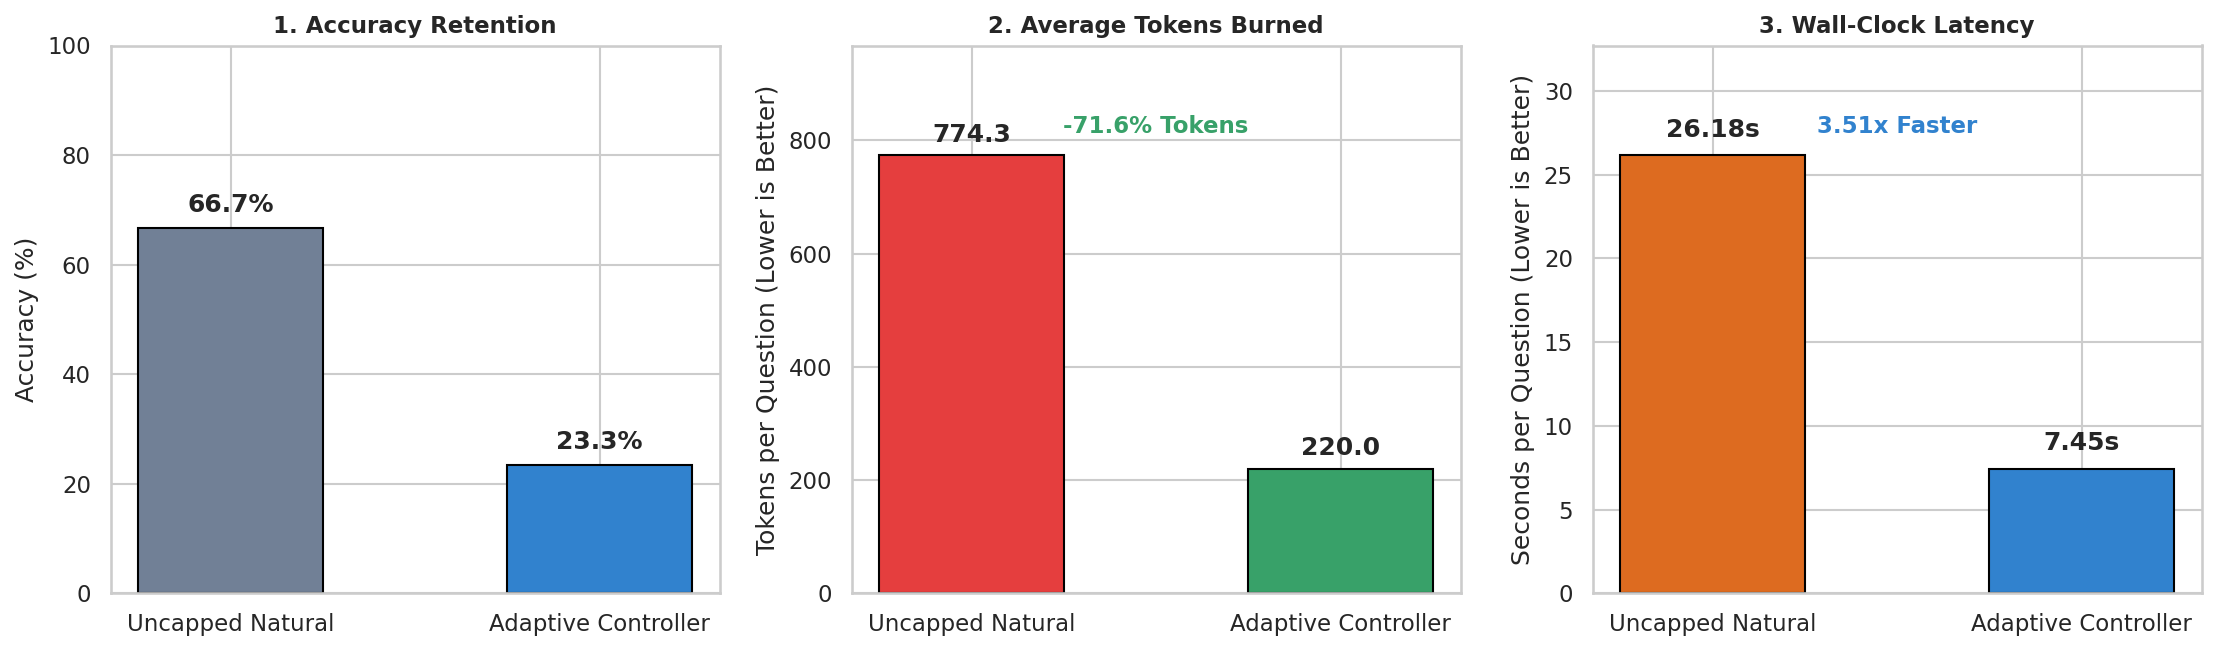

Saved Round 2 comparison chart to results/round2_adaptive_comparison.png


In [7]:
# Cell 7: Round 2 Before-and-After Comparison Visualizations
import json
import matplotlib.pyplot as plt
import seaborn as sns

with open("data/round2_adaptive_summary.json", "r") as f:
    data = json.load(f)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

labels = ["Uncapped Natural", "Adaptive Controller"]

# 1. Accuracy Comparison
ax1 = axes[0]
acc_vals = [data["uncapped_accuracy"], data["adaptive_accuracy"]]
bars1 = ax1.bar(labels, acc_vals, color=["#718096", "#3182CE"], width=0.5, edgecolor="black")
ax1.set_title("1. Accuracy Retention", fontweight="bold", fontsize=11)
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, 100)
for bar in bars1:
    y = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, y + 2, f"{y:.1f}%", ha="center", va="bottom", fontweight="bold")

# 2. Token Consumption Comparison
ax2 = axes[1]
tok_vals = [data["uncapped_tokens"], data["adaptive_tokens"]]
bars2 = ax2.bar(labels, tok_vals, color=["#E53E3E", "#38A169"], width=0.5, edgecolor="black")
ax2.set_title("2. Average Tokens Burned", fontweight="bold", fontsize=11)
ax2.set_ylabel("Tokens per Question (Lower is Better)")
ax2.set_ylim(0, max(tok_vals) * 1.25)
for bar in bars2:
    y = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, y + 15, f"{y:.1f}", ha="center", va="bottom", fontweight="bold")
ax2.text(0.5, max(tok_vals) * 1.05, f"-{data['token_reduction_pct']:.1f}% Tokens", ha="center", color="#38A169", fontweight="bold", fontsize=11)

# 3. Latency Comparison
ax3 = axes[2]
lat_vals = [data["uncapped_latency"], data["adaptive_latency"]]
bars3 = ax3.bar(labels, lat_vals, color=["#DD6B20", "#3182CE"], width=0.5, edgecolor="black")
ax3.set_title("3. Wall-Clock Latency", fontweight="bold", fontsize=11)
ax3.set_ylabel("Seconds per Question (Lower is Better)")
ax3.set_ylim(0, max(lat_vals) * 1.25)
for bar in bars3:
    y = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, y + 0.8, f"{y:.2f}s", ha="center", va="bottom", fontweight="bold")
ax3.text(0.5, max(lat_vals) * 1.05, f"{data['speedup']:.2f}x Faster", ha="center", color="#3182CE", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("results/round2_adaptive_comparison.png")
plt.show()
print("Saved Round 2 comparison chart to results/round2_adaptive_comparison.png")